# Step 4 — Analysis & Research Questions

Using `outputs/classifications.csv` to answer all 4 RQs:

| RQ | Question |
|---|---|
| RQ1 | Which model (GPT vs Gemini) better preserves sentiment overall? |
| RQ2 | Does preservation differ by sentiment class (positive / neutral / negative)? |
| RQ3 | What types of sentiment shifts occur (flip, neutralization, intensification)? |
| RQ4 | Does preservation differ by source language (ES / FR / IT)? |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

CLASS_PATH = r"c:\Users\Nguyen Ngo\Downloads\Thesis Quynh\outputs\classifications.csv"
FIG_DIR    = r"c:\Users\Nguyen Ngo\Downloads\Thesis Quynh\outputs\figures"
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(CLASS_PATH)
# Drop rows with missing sentiment (translation errors)
df = df.dropna(subset=["sentiment"])

print(df.shape)
df["text_type"].value_counts()

(1664, 6)


text_type
reference_en         600
gemini_translated    533
gpt_translated       531
Name: count, dtype: int64

In [2]:
# ── Build comparison table ─────────────────────────────────────────────────────
# Pivot so each (id, source_lang) row has sentiment for all 3 text_types
pivot = df.pivot_table(index=["id", "source_lang"],
                       columns="text_type",
                       values="sentiment",
                       aggfunc="first").reset_index()
pivot.columns.name = None

# Match flags
pivot["gpt_match"]    = (pivot["gpt_translated"]    == pivot["reference_en"]).astype(int)
pivot["gemini_match"] = (pivot["gemini_translated"] == pivot["reference_en"]).astype(int)

print(f"Comparison rows: {len(pivot)}")
pivot.head()

Comparison rows: 600


,id,source_lang,gemini_translated,gpt_translated,reference_en,gpt_match,gemini_match
0,1,French,positive,positive,positive,1,1
1,1,Italian,positive,positive,positive,1,1
2,1,Spanish,positive,positive,positive,1,1
3,2,French,positive,positive,positive,1,1
4,2,Italian,positive,positive,positive,1,1


## RQ1 — Overall sentiment preservation rate

GPT   preservation rate : 79.50%
Gemini preservation rate: 80.67%


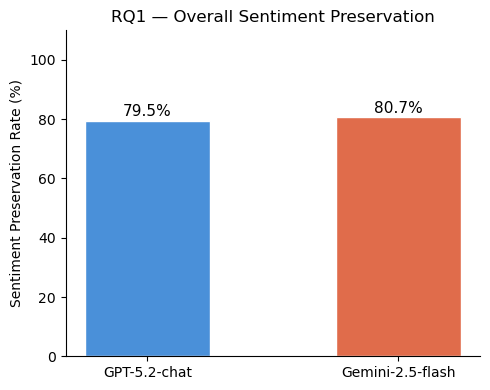

In [3]:
gpt_rate    = pivot["gpt_match"].mean() * 100
gemini_rate = pivot["gemini_match"].mean() * 100

print(f"GPT   preservation rate : {gpt_rate:.2f}%")
print(f"Gemini preservation rate: {gemini_rate:.2f}%")

# Bar chart
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["GPT-5.2-chat", "Gemini-2.5-flash"], [gpt_rate, gemini_rate],
              color=["#4a90d9", "#e06c4b"], edgecolor="white", width=0.5)
for bar, val in zip(bars, [gpt_rate, gemini_rate]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=11)
ax.set_ylim(0, 110)
ax.set_ylabel("Sentiment Preservation Rate (%)")
ax.set_title("RQ1 — Overall Sentiment Preservation")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "rq1_overall.png"), dpi=150)
plt.show()

In [4]:
# Chi-square test — RQ1
ct = pd.DataFrame({
    "GPT":    [pivot["gpt_match"].sum(),    len(pivot) - pivot["gpt_match"].sum()],
    "Gemini": [pivot["gemini_match"].sum(), len(pivot) - pivot["gemini_match"].sum()],
}, index=["match", "no_match"])

chi2, p, dof, _ = chi2_contingency(ct)
print(f"Chi-square: {chi2:.4f}  |  p-value: {p:.4f}  |  df: {dof}")
if p < 0.05:
    print("→ Statistically significant difference between GPT and Gemini.")
else:
    print("→ No statistically significant difference (p ≥ 0.05).")

Chi-square: 0.1881  |  p-value: 0.6645  |  df: 1
→ No statistically significant difference (p ≥ 0.05).


## RQ2 — Preservation by sentiment class

   class   n       GPT    Gemini
positive 258 86.434109 86.434109
 neutral 120 63.333333 65.833333
negative 222 80.180180 81.981982


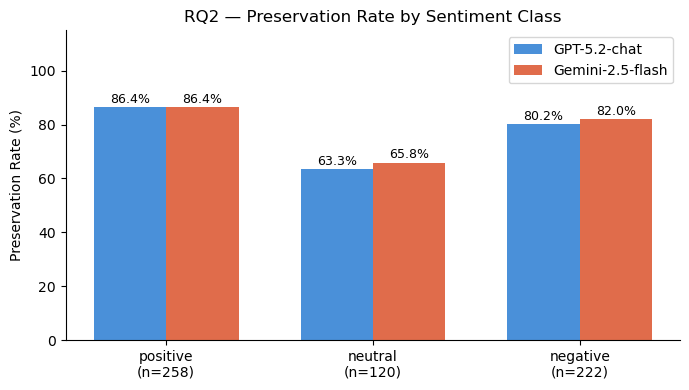

In [5]:
classes = ["positive", "neutral", "negative"]

rq2 = []
for cls in classes:
    subset = pivot[pivot["reference_en"] == cls]
    if len(subset) == 0:
        continue
    rq2.append({
        "class":   cls,
        "n":       len(subset),
        "GPT":     subset["gpt_match"].mean() * 100,
        "Gemini":  subset["gemini_match"].mean() * 100,
    })

rq2_df = pd.DataFrame(rq2)
print(rq2_df.to_string(index=False))

# Grouped bar chart
x = np.arange(len(rq2_df))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - width/2, rq2_df["GPT"],   width, label="GPT-5.2-chat",    color="#4a90d9")
b2 = ax.bar(x + width/2, rq2_df["Gemini"],width, label="Gemini-2.5-flash", color="#e06c4b")
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f"{h:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([f"{r['class']}\n(n={int(r['n'])})" for _, r in rq2_df.iterrows()])
ax.set_ylim(0, 115)
ax.set_ylabel("Preservation Rate (%)")
ax.set_title("RQ2 — Preservation Rate by Sentiment Class")
ax.legend()
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "rq2_by_class.png"), dpi=150)
plt.show()

## RQ3 — Sentiment shift types

In [6]:
def shift_type(ref: str, pred: str) -> str:
    """Categorise how the sentiment changed."""
    if ref == pred:
        return "preserved"
    polarity = {"positive": 1, "neutral": 0, "negative": -1}
    r, p = polarity.get(ref, 0), polarity.get(pred, 0)
    if r * p < 0:                # opposite signs → polarity flip
        return "polarity_flip"
    if p == 0:                   # shifted to neutral
        return "neutralization"
    return "intensity_change"    # same polarity direction, different class

pivot["gpt_shift"]    = pivot.apply(lambda r: shift_type(r["reference_en"], r["gpt_translated"]),    axis=1)
pivot["gemini_shift"] = pivot.apply(lambda r: shift_type(r["reference_en"], r["gemini_translated"]), axis=1)

shift_order = ["preserved", "polarity_flip", "neutralization", "intensity_change"]

for model, col in [("GPT", "gpt_shift"), ("Gemini", "gemini_shift")]:
    counts = pivot[col].value_counts().reindex(shift_order, fill_value=0)
    pct    = (counts / len(pivot) * 100).round(2)
    print(f"\n── {model} ──")
    print(pd.concat([counts.rename("n"), pct.rename("%")], axis=1))


── GPT ──
                    n      %
gpt_shift                   
preserved         477  79.50
polarity_flip      12   2.00
neutralization     83  13.83
intensity_change   28   4.67

── Gemini ──
                    n      %
gemini_shift                
preserved         484  80.67
polarity_flip      11   1.83
neutralization     79  13.17
intensity_change   26   4.33


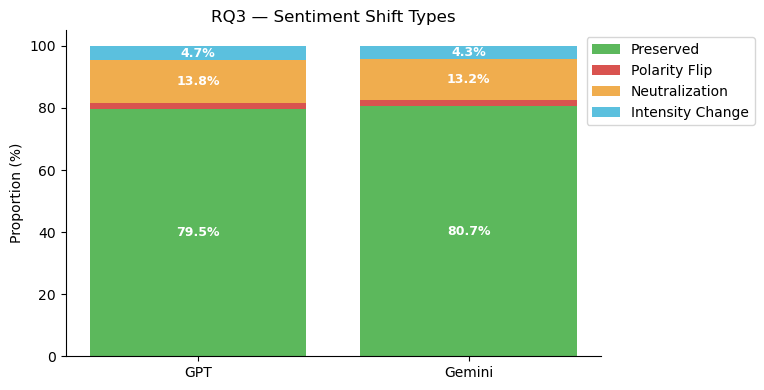

In [7]:
# Stacked bar — shift distribution
shift_colors = {"preserved": "#5cb85c",
                "polarity_flip": "#d9534f",
                "neutralization": "#f0ad4e",
                "intensity_change": "#5bc0de"}

data = {}
for model, col in [("GPT", "gpt_shift"), ("Gemini", "gemini_shift")]:
    data[model] = pivot[col].value_counts().reindex(shift_order, fill_value=0) / len(pivot) * 100

shift_df = pd.DataFrame(data).T

fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(shift_df))
for stype in shift_order:
    vals = shift_df[stype].values
    bars = ax.bar(shift_df.index, vals, bottom=bottom,
                  label=stype.replace("_", " ").title(),
                  color=shift_colors[stype])
    for bar, b, v in zip(bars, bottom, vals):
        if v > 3:
            ax.text(bar.get_x() + bar.get_width()/2, b + v/2,
                    f"{v:.1f}%", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    bottom += vals

ax.set_ylim(0, 105)
ax.set_ylabel("Proportion (%)")
ax.set_title("RQ3 — Sentiment Shift Types")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "rq3_shift_types.png"), dpi=150, bbox_inches="tight")
plt.show()

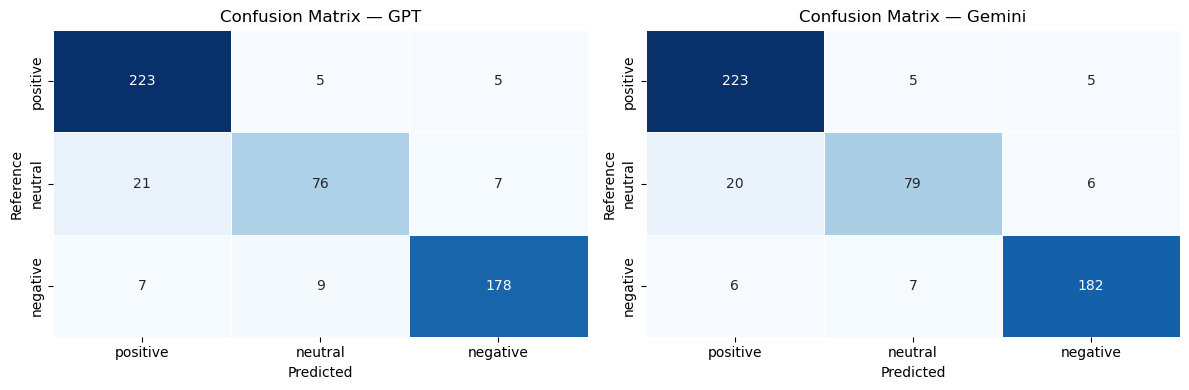

In [8]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ["positive", "neutral", "negative"]

for ax, (model, col) in zip(axes, [("GPT", "gpt_translated"), ("Gemini", "gemini_translated")]):
    cm = pd.crosstab(pivot["reference_en"], pivot[col],
                     rownames=["Reference"], colnames=["Predicted"])
    cm = cm.reindex(index=labels, columns=labels, fill_value=0)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                linewidths=0.5, cbar=False)
    ax.set_title(f"Confusion Matrix — {model}")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "rq3_confusion_matrices.png"), dpi=150)
plt.show()

## RQ4 — Preservation by source language

language   n  GPT  Gemini
 Spanish 200 55.5    55.5
  French 200 92.5    93.0
 Italian 200 90.5    93.5


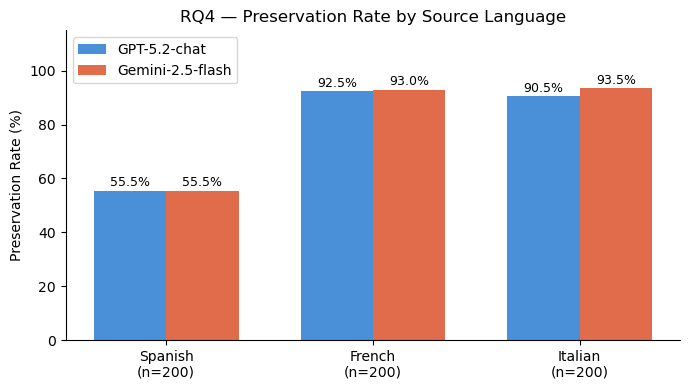

In [9]:
langs = ["Spanish", "French", "Italian"]

rq4 = []
for lang in langs:
    subset = pivot[pivot["source_lang"] == lang]
    rq4.append({
        "language": lang,
        "n":        len(subset),
        "GPT":      subset["gpt_match"].mean() * 100,
        "Gemini":   subset["gemini_match"].mean() * 100,
    })

rq4_df = pd.DataFrame(rq4)
print(rq4_df.to_string(index=False))

# Grouped bar chart
x = np.arange(len(rq4_df))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - width/2, rq4_df["GPT"],   width, label="GPT-5.2-chat",    color="#4a90d9")
b2 = ax.bar(x + width/2, rq4_df["Gemini"],width, label="Gemini-2.5-flash", color="#e06c4b")
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f"{h:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([f"{r['language']}\n(n={int(r['n'])})" for _, r in rq4_df.iterrows()])
ax.set_ylim(0, 115)
ax.set_ylabel("Preservation Rate (%)")
ax.set_title("RQ4 — Preservation Rate by Source Language")
ax.legend()
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "rq4_by_language.png"), dpi=150)
plt.show()

In [10]:
# Chi-square test per language — GPT vs Gemini preservation
print("Chi-square tests per language (GPT vs Gemini match rates):\n")
for lang in langs:
    sub = pivot[pivot["source_lang"] == lang]
    ct = pd.DataFrame({
        "GPT":    [sub["gpt_match"].sum(),    len(sub) - sub["gpt_match"].sum()],
        "Gemini": [sub["gemini_match"].sum(), len(sub) - sub["gemini_match"].sum()],
    }, index=["match", "no_match"])
    chi2, p, _, _ = chi2_contingency(ct)
    sig = "*" if p < 0.05 else "ns"
    print(f"  {lang:10s}  chi2={chi2:.3f}  p={p:.4f}  {sig}")

Chi-square tests per language (GPT vs Gemini match rates):

  Spanish     chi2=0.000  p=1.0000  ns
  French      chi2=0.000  p=1.0000  ns
  Italian     chi2=0.849  p=0.3568  ns


## Summary Table

In [11]:
summary_rows = []

# Overall
summary_rows.append({"Scope": "Overall", "n": len(pivot),
                     "GPT (%)": round(gpt_rate, 2), "Gemini (%)": round(gemini_rate, 2)})

# By class
for _, r in rq2_df.iterrows():
    summary_rows.append({"Scope": r["class"].capitalize(), "n": int(r["n"]),
                         "GPT (%)": round(r["GPT"], 2), "Gemini (%)": round(r["Gemini"], 2)})

# By language
for _, r in rq4_df.iterrows():
    summary_rows.append({"Scope": r["language"], "n": int(r["n"]),
                         "GPT (%)": round(r["GPT"], 2), "Gemini (%)": round(r["Gemini"], 2)})

summary = pd.DataFrame(summary_rows)
summary["Winner"] = summary.apply(
    lambda r: "GPT" if r["GPT (%)"] > r["Gemini (%)"] else ("Gemini" if r["Gemini (%)"] > r["GPT (%)"] else "Tie"), axis=1
)
print(summary.to_string(index=False))

OUT_SUMMARY = r"c:\Users\Nguyen Ngo\Downloads\Thesis Quynh\outputs\summary_results.csv"
summary.to_csv(OUT_SUMMARY, index=False)
print(f"\nSummary saved → {OUT_SUMMARY}")

   Scope   n  GPT (%)  Gemini (%) Winner
 Overall 600    79.50       80.67 Gemini
Positive 258    86.43       86.43    Tie
 Neutral 120    63.33       65.83 Gemini
Negative 222    80.18       81.98 Gemini
 Spanish 200    55.50       55.50    Tie
  French 200    92.50       93.00 Gemini
 Italian 200    90.50       93.50 Gemini

Summary saved → c:\Users\Nguyen Ngo\Downloads\Thesis Quynh\outputs\summary_results.csv
